# 0. Load

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, roc_auc_score, f1_score

In [3]:
df_org = pd.read_csv("../Data/churn_processed.csv")
df_org.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,3.0,229.53
1,52942,0,13.0,Computer,1,9.0,COD,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,2.0,9.0,234.38
2,52972,0,16.0,Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07
3,53125,0,5.0,Phone,1,16.0,Debit Card,Male,3.0,4,Fashion,4,Married,3,0,26.0,2.0,2.0,9.0,231.48
4,53367,0,9.0,Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165.14


# 1. Preprocess

In [4]:
df = df_org.copy()

In [5]:
df['CityTier'] = df['CityTier'].astype("str")
df = df.drop(columns = "CustomerID")

In [6]:
df = pd.get_dummies(df, drop_first = True)

# 2. Feature importance

## a. Split

In [7]:
x = df.drop(columns = "Churn")
y = df[["Churn"]].values.ravel()

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 10)

## b. Fit model

In [8]:
model = RandomForestClassifier(random_state = 10)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred, digits = 4))

              precision    recall  f1-score   support

           0     0.9582    0.9943    0.9759      1407
           1     0.9652    0.7845    0.8655       283

    accuracy                         0.9592      1690
   macro avg     0.9617    0.8894    0.9207      1690
weighted avg     0.9594    0.9592    0.9574      1690



## c. Extract features

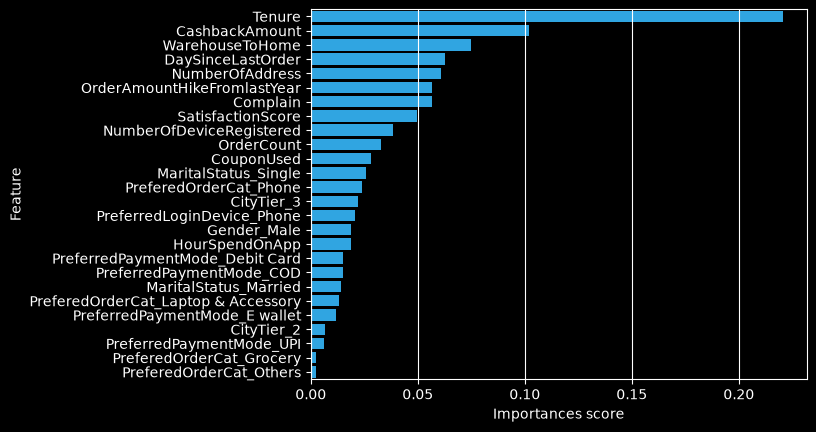

In [9]:
imp = pd.DataFrame({
    "Feature": model.feature_names_in_,
    "Importances score": model.feature_importances_
}).sort_values("Importances score", ascending = False)

plt.style.use('dark_background')
plt.grid(axis = 'x', color = "#ffffff")
sns.barplot(data = imp, x = "Importances score", y = "Feature", color = "#12aeff")
plt.show()

In [10]:
threshold = 0.05
imp_ft = imp[imp["Importances score"] > threshold]["Feature"].to_list()

In [11]:
df[imp_ft].head()

,Tenure,CashbackAmount,WarehouseToHome,DaySinceLastOrder,NumberOfAddress,OrderAmountHikeFromlastYear,Complain
0,20.0,229.53,7.0,3.0,3,26.0,0
1,13.0,234.38,9.0,9.0,2,26.0,0
2,16.0,174.07,7.0,7.0,3,26.0,0
3,5.0,231.48,16.0,9.0,3,26.0,0
4,9.0,165.14,28.0,8.0,3,26.0,1


# 3. EDA

## a. Churn vs No churn

In [12]:
df_eda = df[imp_ft].copy()
df_eda["Churn"] = df["Churn"]
df_eda.head()

,Tenure,CashbackAmount,WarehouseToHome,DaySinceLastOrder,NumberOfAddress,OrderAmountHikeFromlastYear,Complain,Churn
0,20.0,229.53,7.0,3.0,3,26.0,0,0
1,13.0,234.38,9.0,9.0,2,26.0,0,0
2,16.0,174.07,7.0,7.0,3,26.0,0,0
3,5.0,231.48,16.0,9.0,3,26.0,0,0
4,9.0,165.14,28.0,8.0,3,26.0,1,0


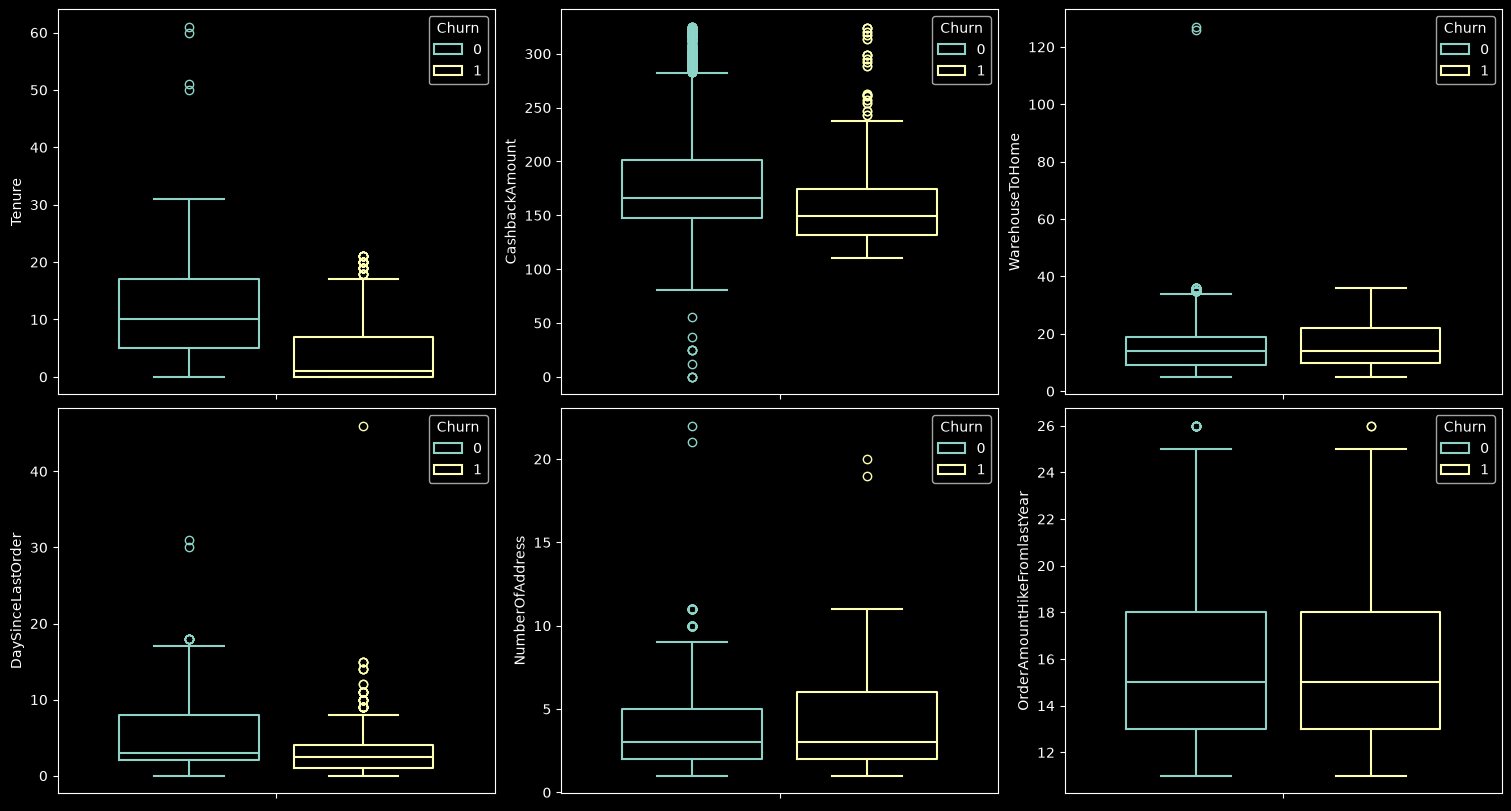

In [22]:
sns.set_palette('Blues')
plt.style.use('dark_background')
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15, 8), constrained_layout = True)
axes = axes.ravel()
for i in range(len(imp_ft[:-1])):
    sns.boxplot(data = df_eda, y = imp_ft[i], hue = "Churn",
                fill = False, linewidth = 1.5, gap = 0.2, ax = axes[i])
plt.show()

<Axes: xlabel='Churn', ylabel='proportion'>

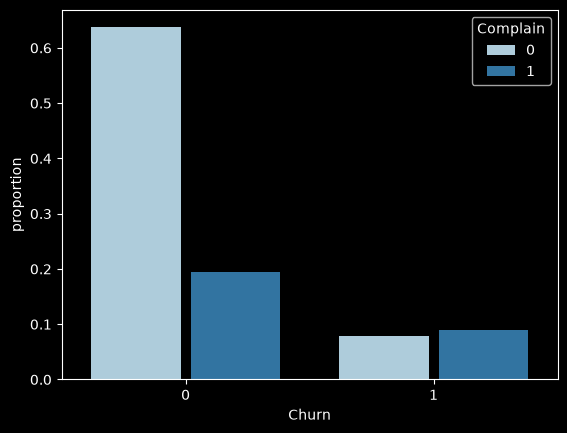

In [14]:
sns.set_palette('Paired')
sns.countplot(data = df_eda, x = "Churn", hue = "Complain", stat= 'proportion', fill = True, gap = 0.1)

## b. Churn rate

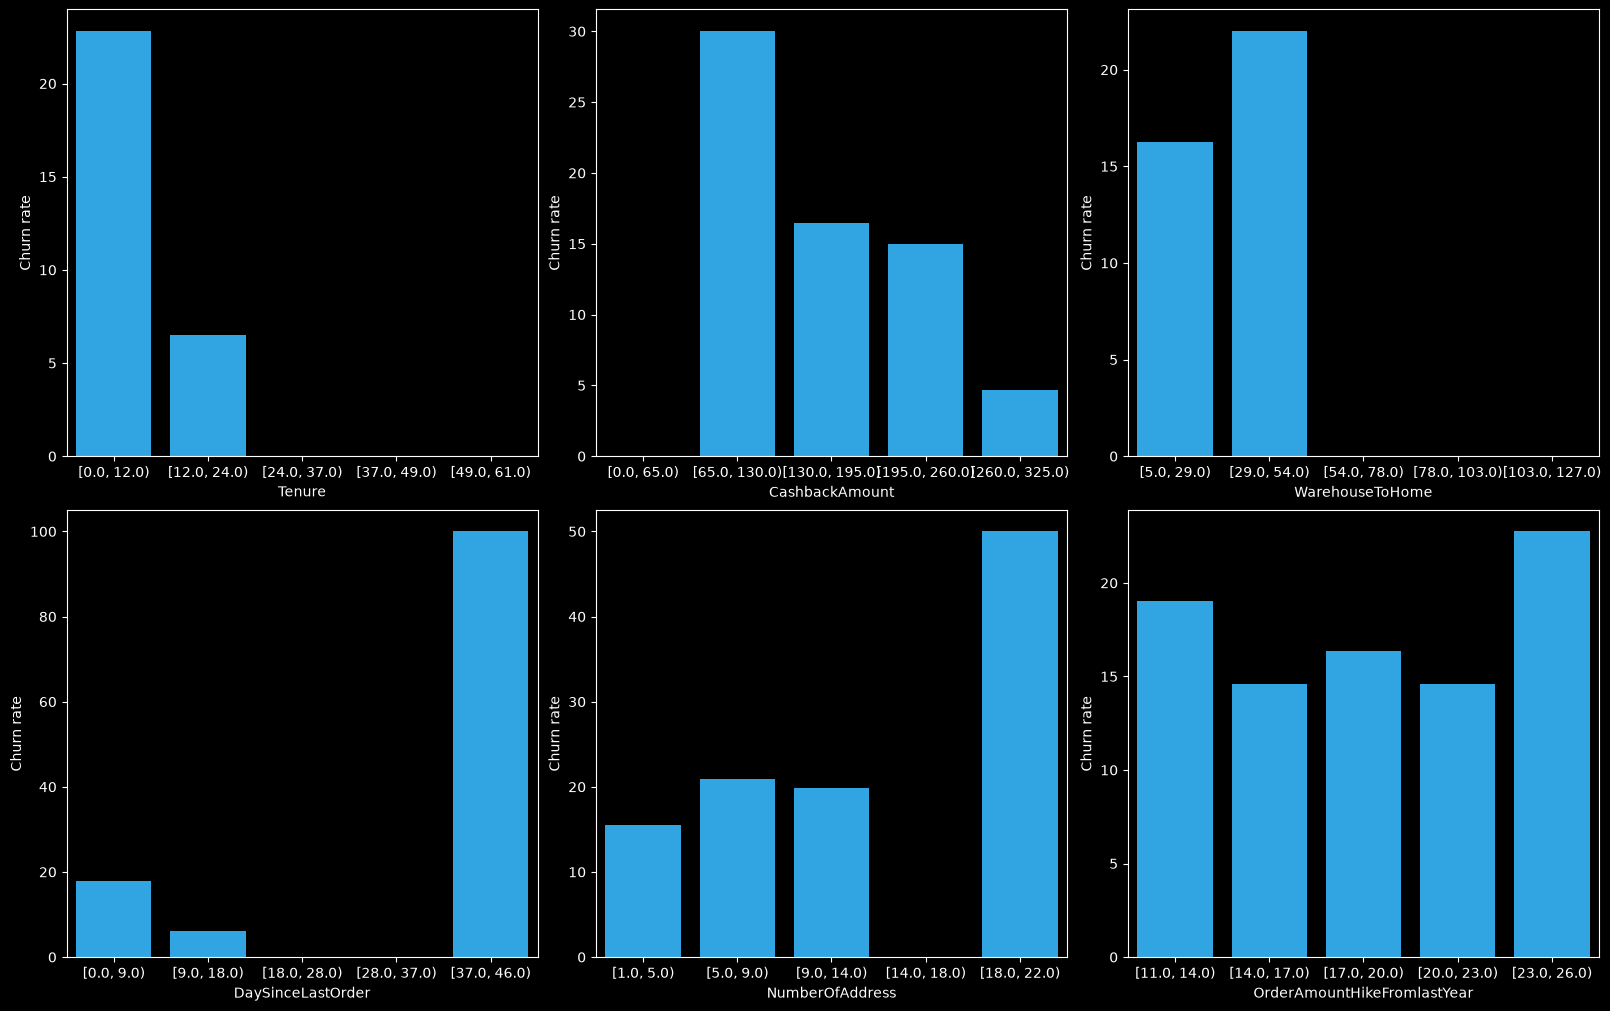

In [15]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (16, 10), constrained_layout = True)
axes = axes.ravel()
for i in range(len(imp_ft[:-1])):
    df_cut = pd.cut(df_eda[imp_ft[i]], bins = 5, right = False, precision = 0).to_frame()
    df_cut["Churn"] = df_eda["Churn"]
    df_cut = df_cut.groupby(imp_ft[i]).agg(
        Total = ("Churn", "sum"),
        All = ("Churn", "count")
    )
    df_cut["Churn rate"] = (df_cut["Total"].mul(100)/df_cut["All"]).round(2)
    sns.barplot(df_cut, x = imp_ft[i], y = "Churn rate",
                color = "#12aeff", fill = True, linewidth = 2,
                ax = axes[i])
plt.show()

# 4. Key takeaways

Insights:
- New users tend to churn more
- Users with lower Cashback Amount are more likely to churn more
- Customers with high number of addresses & long time no order have higher chance of churn

Suggestions:
- Focus on new customers and customers with last order > 1 month, launch cashback promotions for them to acquire/retain
- Aware of customers with high number of addresses, limit the number of addresses can be added or implement verify identity in order to reduce the risk of fraud